In [1]:
!pip install pyodbc

In [2]:
!pip install pandas
!pip install numpy

In [17]:
import pandas as pd
import numpy as np
import pyodbc
import warnings
warnings.filterwarnings('ignore')

In [4]:
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server']


In [63]:
 conn = pyodbc.connect(
        'Driver={ODBC Driver 17 for SQL Server};' 'server=Padma-Krishna-Murthy\\PADMA;' 'Database=task;' 'Trusted_Connection=yes')


In [64]:
if conn:
    print("True")

True


In [65]:
#create a cursor
cursor = conn.cursor()

In [66]:
#execute a query
cursor.execute("select * from sales_data_sample") 

In [67]:
#fetch all rows
rows = cursor.fetchall()
for row in rows:
    print(row)

(10107, 30, 95.69999694824219, 2, 2871.0, datetime.datetime(2003, 2, 24, 0, 0), 'Shipped', 1, 2, 2003, 'Motorcycles', 95, 'S10_1678', 'Land of Toys Inc.', '2125557818', '897 Long Airport Avenue', None, 'NYC', 'NY', '10022', 'USA', 'NA', 'Yu', 'Kwai', 'Small')
(10121, 34, 81.3499984741211, 5, 2765.89990234375, datetime.datetime(2003, 5, 7, 0, 0), 'Shipped', 2, 5, 2003, 'Motorcycles', 95, 'S10_1678', 'Reims Collectables', '26.47.1555', "59 rue de l'Abbaye", None, 'Reims', None, '51100', 'France', 'EMEA', 'Henriot', 'Paul', 'Small')
(10134, 41, 94.73999786376953, 2, 3884.340087890625, datetime.datetime(2003, 7, 1, 0, 0), 'Shipped', 3, 7, 2003, 'Motorcycles', 95, 'S10_1678', 'Lyon Souveniers', '+33 1 46 62 7555', '27 rue du Colonel Pierre Avia', None, 'Paris', None, '75508', 'France', 'EMEA', 'Da Cunha', 'Daniel', 'Medium')
(10145, 45, 83.26000213623047, 6, 3746.699951171875, datetime.datetime(2003, 8, 25, 0, 0), 'Shipped', 3, 8, 2003, 'Motorcycles', 95, 'S10_1678', 'Toys4GrownUps.com', '6

In [68]:
# Query the data
query = "SELECT * FROM sales_data" # Replace with your actual table name
df = pd.read_sql("select top 10 * from sales_data_sample",conn)

# Show the first few rows
print(df)



   ORDERNUMBER  QUANTITYORDERED   PRICEEACH  ORDERLINENUMBER        SALES  \
0        10107               30   95.699997                2  2871.000000   
1        10121               34   81.349998                5  2765.899902   
2        10134               41   94.739998                2  3884.340088   
3        10145               45   83.260002                6  3746.699951   
4        10159               49  100.000000               14  5205.270020   
5        10168               36   96.660004                1  3479.760010   
6        10180               29   86.129997                9  2497.770020   
7        10188               48  100.000000                1  5512.319824   
8        10201               22   98.570000                2  2168.540039   
9        10211               41  100.000000               14  4708.439941   

   ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0 2003-02-24  Shipped       1         2     2003  ...   
1 2003-05-07  Shipped       2         

In [69]:
# Count frequency of CUSTOMERNAME
common_customers = df['CUSTOMERNAME'].value_counts()

# Display all customers that appear more than once
print("Common customer names in top 10 rows:")
print(common_customers[common_customers > 1])

Common customer names in top 10 rows:
Series([], Name: count, dtype: int64)


In [70]:
!pip install matplotlib.pyplot

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


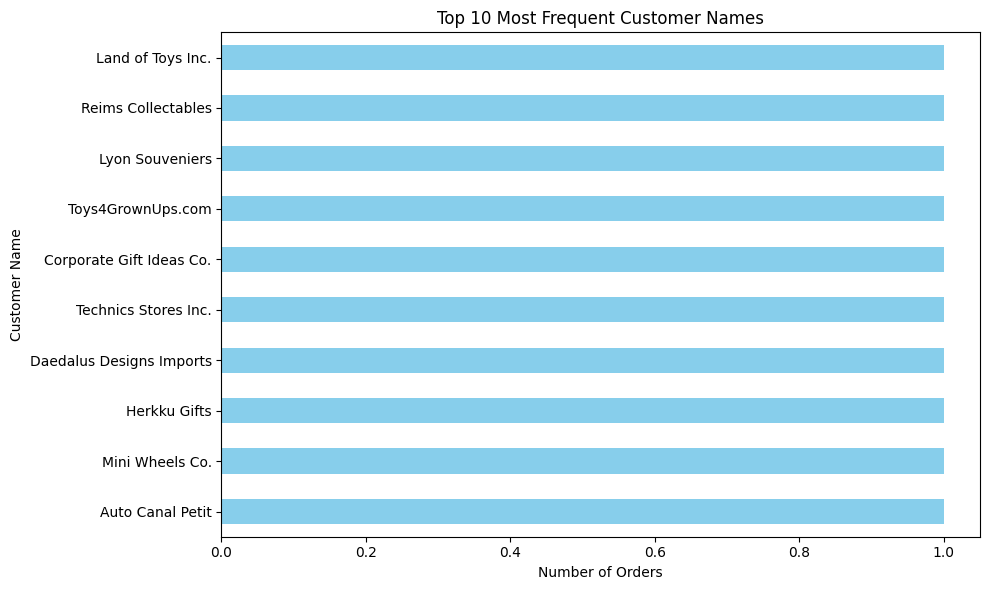

In [71]:

import matplotlib.pyplot as plt

# Count top 10 most frequent customer names
top_customers = df['CUSTOMERNAME'].value_counts().head(10)

# Plot the bar chart
plt.figure(figsize=(10, 6))
top_customers.plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Frequent Customer Names')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()
plt.show()

In [72]:
!pip install seaborn
import seaborn as sns

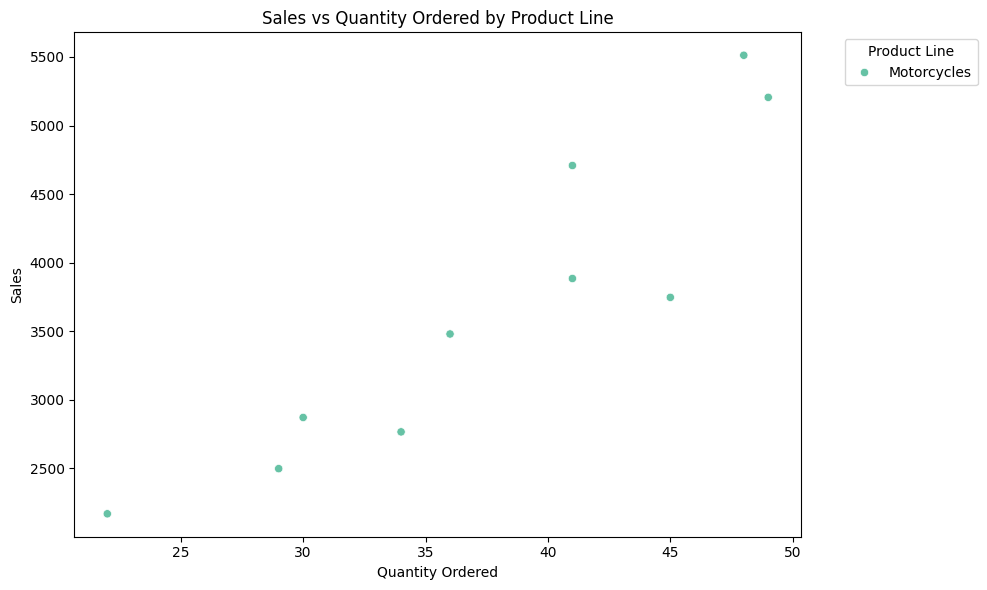

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='QUANTITYORDERED', y='SALES', hue='PRODUCTLINE', palette='Set2')

plt.title('Sales vs Quantity Ordered by Product Line')
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales')
plt.legend(title='Product Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

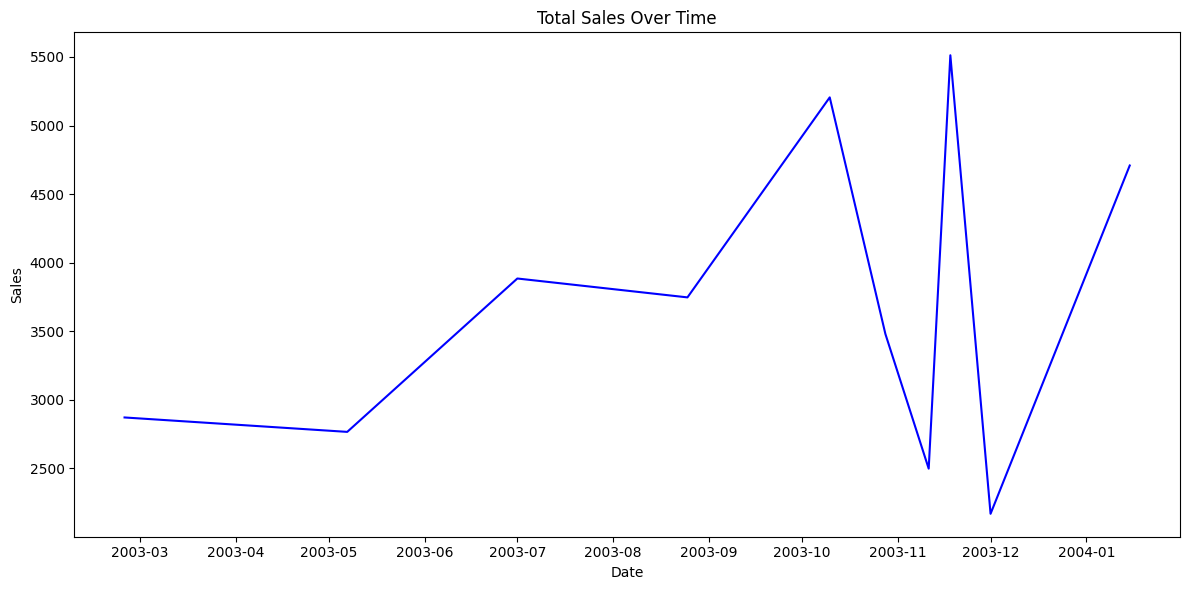

In [74]:
# Make sure ORDERDATE is a datetime type
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Group by date and sum the sales
sales_over_time = df.groupby('ORDERDATE')['SALES'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_over_time, x='ORDERDATE', y='SALES', color='blue')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()